## Imports

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Activation,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dropout,
    BatchNormalization,
    GlobalMaxPool2D,
)
from tensorflow.keras.applications import ResNet50V2

In [29]:
%matplotlib inline

In [30]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Utils

In [31]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

## EDA

In [32]:
dataset_dir = "../data/dogs_vs_cats"
train_dir = f"{dataset_dir}/train"
test_dir = f"{dataset_dir}/test"

In [33]:
print("Loading Training Data:")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=(224, 224), batch_size=32
)

print("\nLoading Test/Validation Data:")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=(224, 224), batch_size=32
)

Loading Training Data:
Found 20000 files belonging to 2 classes.

Loading Test/Validation Data:
Found 5000 files belonging to 2 classes.


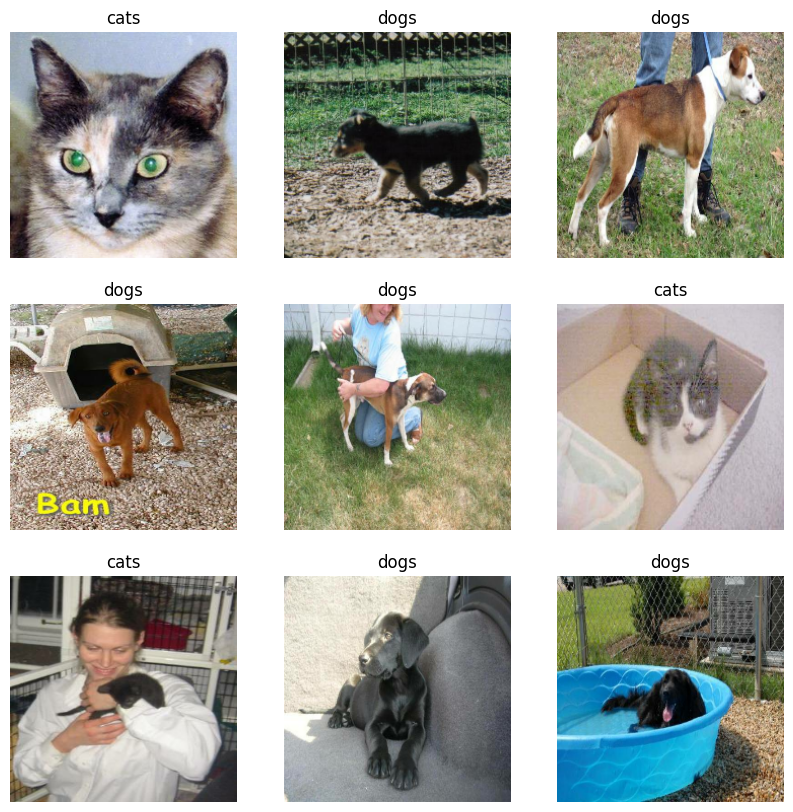

In [34]:
class_names = train_dataset.class_names

plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

In [35]:
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.2),
        tf.keras.layers.RandomZoom(height_factor=(-0.3, -0.2)),
    ]
)

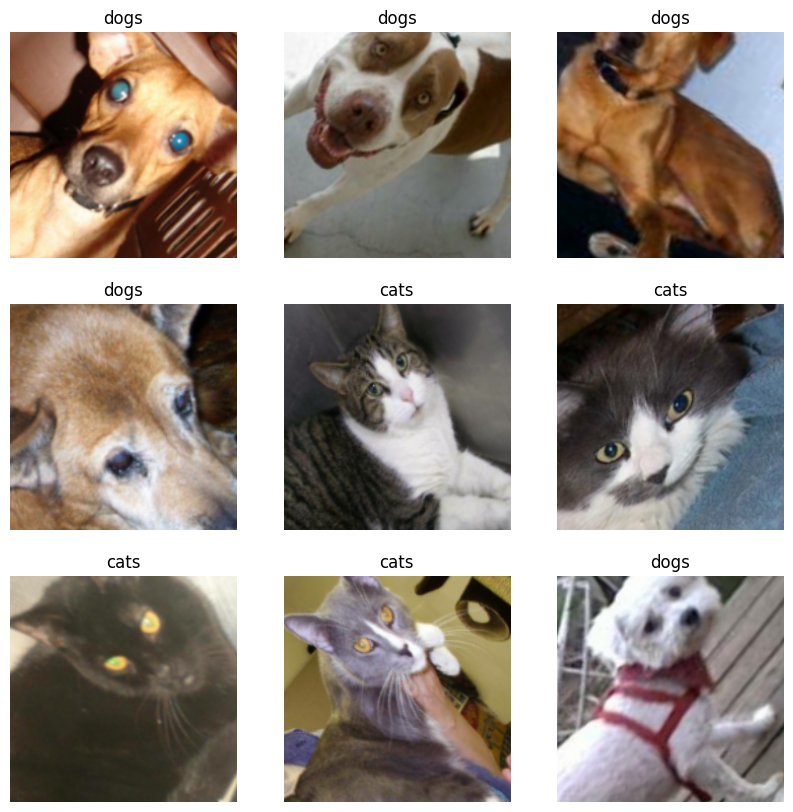

In [36]:
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1):
    augmented_images = data_augmentation(images)
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.show()

## CNN

In [37]:
if not os.path.exists("models"):
    os.makedirs("models")

In [38]:
model = Sequential()

model.add(tf.keras.Input(shape=(224, 224, 3)))

model.add(data_augmentation)

# Block 1
model.add(Conv2D(filters=32, padding='same', kernel_size=(7,7))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D(pool_size=(2,2))) 
model.add(Dropout(0.2)) 

# Block 2
model.add(Conv2D(filters=64, padding='valid', kernel_size=(5,5))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D(pool_size=(2,2))) 
model.add(Dropout(0.2)) 

# Block 3
model.add(Conv2D(filters=128, padding='valid', kernel_size=(3,3))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D()) 
model.add(Dropout(0.2)) 

# Block 4
model.add(Conv2D(filters=256, padding='valid', kernel_size=(3,3))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(Conv2D(filters=256, kernel_size=(3,3))) 
model.add(Activation('relu')) 
model.add(BatchNormalization()) 
model.add(MaxPooling2D(pool_size=(2,2))) 
model.add(Dropout(0.2)) 

# Final Layers
model.add(GlobalMaxPool2D()) 
model.add(Dense(units=256)) 
model.add(Activation('relu')) 
model.add(Dropout(0.2)) 
model.add(Dense(units=1)) 
model.add(Activation('sigmoid')) 

model.summary()
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_20 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 108, 108, 64)   │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_21 (Activation)      │ (None, 108, 108, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 108, 108, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_22 (Activation)      │ (None, 52, 52, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_23 (Activation)      │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 22, 22, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_24 (Activation)      │ (None, 22, 22, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 22, 22, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,084,097 (4.14 MB)

 Trainable params: 1,082,625 (4.13 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [39]:
model_path = 'models/model_cnn_cats_dogs.keras'

if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    model = tf.keras.models.load_model(model_path)
# else:
    # history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)
    
    # loss, accuracy = model.evaluate(val_dataset)
    # print(f"Validation Accuracy: {accuracy*100:.2f}%")
    
    # plot_history(history, title="CNN Model Performance")
    
    # model.save(model_path)
    # print(f"Model saved to '{model_path}'!")

In [40]:
model_simple = Sequential()

# Input
model_simple.add(tf.keras.Input(shape=(224, 224, 3)))
model_simple.add(data_augmentation)

# Block 1
model_simple.add(Conv2D(filters=32, kernel_size=(3, 3), padding="same"))
model_simple.add(Activation("relu"))
model_simple.add(MaxPooling2D(pool_size=(2, 2)))

# Block 2
model_simple.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same"))
model_simple.add(Activation("relu"))
model_simple.add(MaxPooling2D(pool_size=(2, 2)))

# Classification Layer
model_simple.add(GlobalMaxPool2D())
model_simple.add(Dense(units=128))
model_simple.add(Activation("relu"))
model_simple.add(Dropout(0.2))
model_simple.add(Dense(units=1))
model_simple.add(Activation("sigmoid"))

model_simple.summary()
model_simple.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_5          │ (None, 64)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_30 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,841 (108.75 KB)

 Trainable params: 27,841 (108.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 52s 82ms/step - accuracy: 0.5209 - loss: 3.2798 - val_accuracy: 0.5756 - val_loss: 1.0635
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.5705 - loss: 1.3709 - val_accuracy: 0.6228 - val_loss: 0.7545
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.6209 - loss: 0.7680 - val_accuracy: 0.6062 - val_loss: 0.7490
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.6582 - loss: 0.6335 - val_accuracy: 0.6610 - val_loss: 0.6382
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.6783 - loss: 0.6053 - val_accuracy: 0.6632 - val_loss: 0.6261
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.6838 - loss: 0.5994 - val_accuracy: 0.6550 - val_loss: 0.6630
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.7027 - loss: 0.5803 - val_accuracy: 0.6746 - val_loss: 0.6401
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 50s 81ms/step - accuracy: 0.7128 - loss: 0.5773 - 

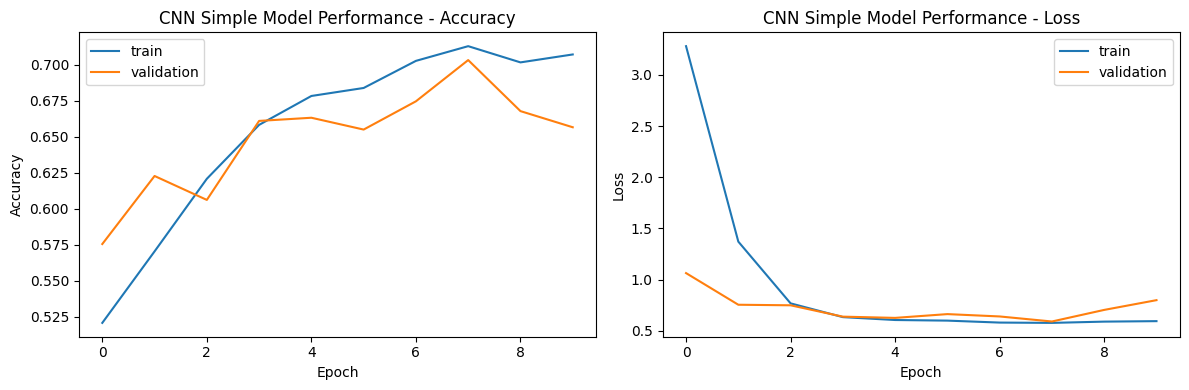

Model saved to 'models/simple_cnn_cats_dogs.keras'!


In [41]:
model_path = 'models/simple_cnn_cats_dogs.keras'


if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    model_simple = tf.keras.models.load_model(model_path)
else:
    history = model_simple.fit(train_dataset, validation_data=val_dataset, epochs=10)
    
    loss, accuracy = model_simple.evaluate(val_dataset)
    print(f"Validation Accuracy: {accuracy*100:.2f}%")
    
    plot_history(history, title="CNN Simple Model Performance")
    
    model_simple.save(model_path)
    print(f"Model saved to '{model_path}'!")

In [42]:
base_model = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False 

resnet_model = Sequential()

resnet_model.add(base_model)

resnet_model.add(GlobalMaxPool2D())
resnet_model.add(Dense(units=128))
resnet_model.add(Activation("relu"))
resnet_model.add(Dropout(0.2))
resnet_model.add(Dense(units=1))
resnet_model.add(Activation("sigmoid"))

resnet_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Training ResNet50 Comparison Model...
Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 103s 159ms/step - accuracy: 0.5511 - loss: 143.9407 - val_accuracy: 0.6488 - val_loss: 26.7571
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.5827 - loss: 52.3220 - val_accuracy: 0.6778 - val_loss: 7.1687
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 95s 153ms/step - accuracy: 0.5743 - loss: 10.0786 - val_accuracy: 0.5242 - val_loss: 3.8941
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 118ms/step - accuracy: 0.5242 - loss: 3.8941
ResNet Validation Accuracy: 52.42%


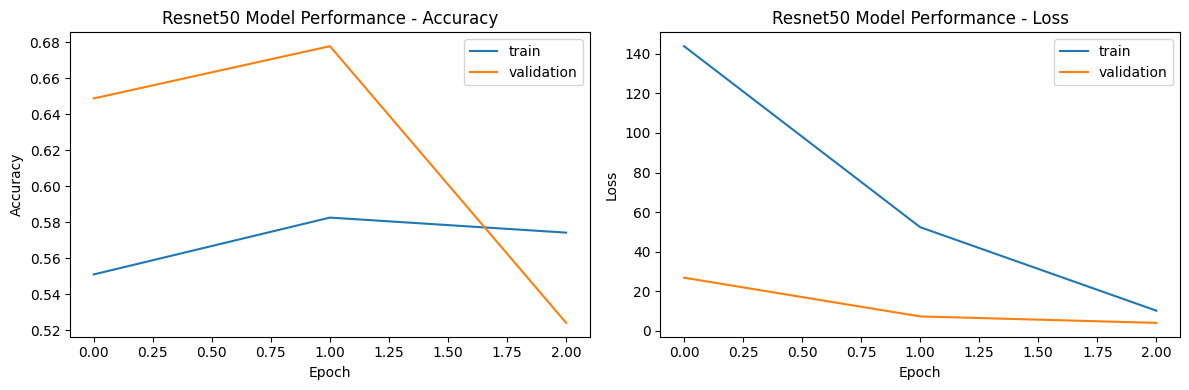

Model saved to 'models/resnet50_cats_dogs.keras'!


In [43]:
model_path = 'models/resnet50_cats_dogs.keras'

if os.path.exists(model_path):
    print(f"Loading model from {model_path}...")
    resnet_model = tf.keras.models.load_model(model_path)
else:
    pass
    print("Training ResNet50 Comparison Model...")
    history_resnet = resnet_model.fit(train_dataset, validation_data=val_dataset, epochs=3)
    
    loss, accuracy = resnet_model.evaluate(val_dataset)
    print(f"ResNet Validation Accuracy: {accuracy*100:.2f}%")
    
    plot_history(history_resnet, title="Resnet50 Model Performance")
    
    resnet_model.save(model_path)
    print(f"Model saved to '{model_path}'!")